In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
X_train_scaled=np.load('../data/X_train_scaled.npy')
X_test_scaled=np.load('../data/X_test_scaled.npy')
y_train_resampled=np.load('../data/y_train_resampled.npy')
y_test=np.load('../data/y_test.npy')
feature_cols=joblib.load('../model/feature_cols.pkl')

In [4]:
X_train_scaled.shape

(452296, 145)

In [5]:
y_train_resampled.shape

(452296,)

In [6]:
#Baseline Accuracy 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,roc_auc_score,roc_curve
from sklearn.model_selection import cross_val_score
baseline=LogisticRegression(max_iter=1000, random_state=42)
baseline.fit(X_train_scaled,y_train_resampled)
baseline_pred=baseline.predict(X_test_scaled)
baseline_acc=accuracy_score(y_test,baseline_pred)
print(f"Baseline LR:{baseline_acc:.4f}")

Baseline LR:0.9181


In [7]:
from xgboost import XGBClassifier
xgb=XGBClassifier(n_estimators=300, max_depth=6,
                 learning_rate=0.05, scale_pos_weight=10,
                 subsample=0.8, colsample_bytree=0.8,
                 random_state=42, eval_metric='auc')
xgb.fit(X_train_scaled,y_train_resampled)
xgb_pred=xgb.predict(X_test_scaled)
xgb_proba=xgb.predict_proba(X_test_scaled)[:,1]

In [8]:
print(f"XGBoost:{accuracy_score(y_test,xgb_pred):.4f}")
print(f"ROC-AUC:{roc_auc_score(y_test,xgb_proba):.4f}")
print(classification_report(y_test,xgb_pred))

XGBoost:0.7053
ROC-AUC:0.7507
              precision    recall  f1-score   support

           0       0.96      0.71      0.82     56538
           1       0.17      0.65      0.26      4965

    accuracy                           0.71     61503
   macro avg       0.56      0.68      0.54     61503
weighted avg       0.89      0.71      0.77     61503



In [10]:
!pip install optuna


   ---------------------------------------- 0/2 [colorlog]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ----

In [12]:
import optuna
def objective(trail):
    params={
        'n_estimators':trail.suggest_int('n_estimators',100,500),
        'max_depth':trail.suggest_int('max_depth',3,10),
        'learning_rate':trail.suggest_float('learning_rate',0.01,0.3),
        'subsample':trail.suggest_float('subsample',0.6,1.0),
        'colsample_bytree':trail.suggest_float('colsample_bytree',0.6,1.0),
        'scale_pos_weight':trail.suggest_int('scale_pos_weight',5,15)
    }
    model=XGBClassifier(**params, random_state=42)
    score=cross_val_score(model,X_train_scaled,y_train_resampled,cv=3,scoring='accuracy').mean()
    return score

study=optuna.create_study(direction='maximize')
study.optimize(objective,n_trials=50)

print(f"Best params:{study.best_params}")
print(f"Best CV accuracy:{study.best_value:.4f}")

[I 2026-09-24 18:59:41,275] A new study created in memory with name: no-name-f2a40d44-0f27-4876-8cd6-12236ebb9dbe
[I 2026-09-24 19:00:00,651] Trial 0 finished with value: 0.8918496382491803 and parameters: {'n_estimators': 256, 'max_depth': 4, 'learning_rate': 0.17422222668677975, 'subsample': 0.768381922813918, 'colsample_bytree': 0.9099471560911917, 'scale_pos_weight': 5}. Best is trial 0 with value: 0.8918496382491803.
[I 2026-09-24 19:00:21,604] Trial 1 finished with value: 0.8402947892579271 and parameters: {'n_estimators': 168, 'max_depth': 9, 'learning_rate': 0.15006741949972946, 'subsample': 0.7993514828682495, 'colsample_bytree': 0.6115131960636386, 'scale_pos_weight': 15}. Best is trial 0 with value: 0.8918496382491803.
[I 2026-09-24 19:00:51,626] Trial 2 finished with value: 0.8270180563136336 and parameters: {'n_estimators': 479, 'max_depth': 4, 'learning_rate': 0.2285236076135452, 'subsample': 0.7406986071128122, 'colsample_bytree': 0.799360669151793, 'scale_pos_weight': 1

Best params:{'n_estimators': 310, 'max_depth': 10, 'learning_rate': 0.29665060697573675, 'subsample': 0.8232824142684791, 'colsample_bytree': 0.9504055839593919, 'scale_pos_weight': 6}
Best CV accuracy:0.9362


In [13]:
final_model=XGBClassifier(**study.best_params,random_state=42)
final_model.fit(X_train_scaled,y_train_resampled)
final_pred=final_model.predict(X_test_scaled)
final_proba=final_model.predict_proba(X_test_scaled)[:,1]

In [15]:
print(f"Final Accuracy:{accuracy_score(y_test,final_pred):.4f}")
print(f"Final ROC-AUC:{roc_auc_score(y_test,final_proba):.4f}")

Final Accuracy:0.9007
Final ROC-AUC:0.7042


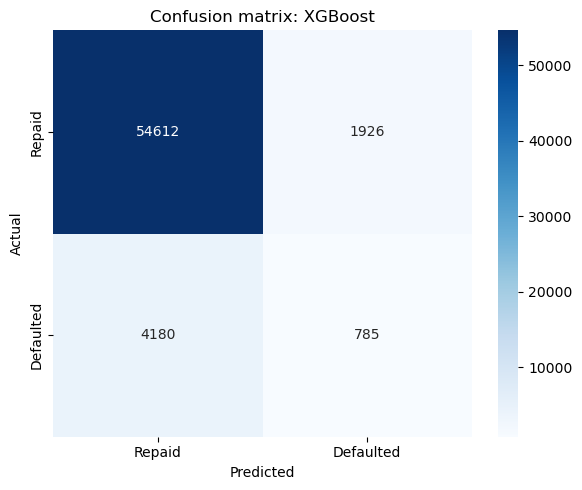

In [17]:
#confusion matrix
cm=confusion_matrix(y_test,final_pred)
fig,ax=plt.subplots(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',ax=ax,
           xticklabels=['Repaid','Defaulted'], yticklabels=['Repaid','Defaulted'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion matrix: XGBoost')
plt.tight_layout()
plt.savefig('../assets/confusion_matrix.png',dpi=150,bbox_inches='tight')
plt.show()